📌 PARTE 1 — Importação das Bibliotecas

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)

📌 PARTE 2 — Carregamento dos Dados

In [58]:
df = pd.read_csv("/content/dados_tratados.csv")

df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [60]:
df.describe()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2.158675,64.761692,2279.734304
std,24.559481,1.003088,30.090047,2266.794470
min,0.000000,0.610000,18.250000,0.000000
25%,9.000000,1.180000,35.500000,398.550000
50%,29.000000,2.340000,70.350000,1394.550000
75%,55.000000,2.990000,89.850000,3786.600000
max,72.000000,3.960000,118.750000,8684.800000


In [61]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

📌 PARTE 3 — LIMPEZA E CORREÇÕES IMPORTANTES

🔥 1) Remover ID (se existir)

In [62]:
if "CustomerID" in df.columns:
    df = df.drop("CustomerID", axis=1)

🔥 2) Converter colunas numéricas que vieram como string

In [63]:
for col in df.columns:
    if df[col].dtype == "object":
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

🔥 3) Aplicar OneHotEncoding automaticamente nas categóricas

In [64]:
df = pd.get_dummies(df, drop_first=True)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 7043 non-null   int64  
 1   ChargesDaily                           7043 non-null   float64
 2   ChargesMonthly                         7043 non-null   float64
 3   ChargesTotal                           7043 non-null   float64
 4   Churn_Yes                              7043 non-null   bool   
 5   Gender_Male                            7043 non-null   bool   
 6   SeniorCitizen_Yes                      7043 non-null   bool   
 7   Partner_Yes                            7043 non-null   bool   
 8   Dependents_Yes                         7043 non-null   bool   
 9   PhoneService_Yes                       7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  Inte

📌 PARTE 4 — Definir Variável Alvo

In [66]:
for col in df.columns:
    if "churn" in col.lower():
        print(col)

Churn_Yes


In [67]:
target = "Churn_Yes"

X = df.drop(target, axis=1)
y = df[target]

In [68]:
#df

df.columns

Index(['Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal', 'Churn_Yes',
       'Gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

📌 PARTE 5 — Escalonamento

In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

📌 PARTE 6 — Divisão Treino/Teste

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

📌 PARTE 7 — Treinar Modelos

🔵 Regressão Logística

In [71]:
modelo_lr = LogisticRegression(max_iter=2000)
modelo_lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

🟢 Random Forest

In [72]:
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

🟣 Gradient Boosting

In [73]:
modelo_gb = GradientBoostingClassifier(random_state=42)
modelo_gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

📌 PARTE 8 — Função de Avaliação Completa

In [84]:
def avaliar_modelo(nome, modelo):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]

    print(f"\n===== {nome} =====")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("Precisão:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nRelatório:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1])
    plt.title(f"Curva ROC - {nome}")
    plt.show()

📌 PARTE 9 — Avaliar os modelos (Regressão Logística - Random Forest - Gradient Boosting)


===== Regressão Logística =====
Acurácia: 0.7979176526265973
Precisão: 0.6401673640167364
Recall: 0.5454545454545454
F1-Score: 0.5890279114533205
ROC-AUC: 0.840360089677858

Relatório:
              precision    recall  f1-score   support

       False       0.84      0.89      0.87      1552
        True       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



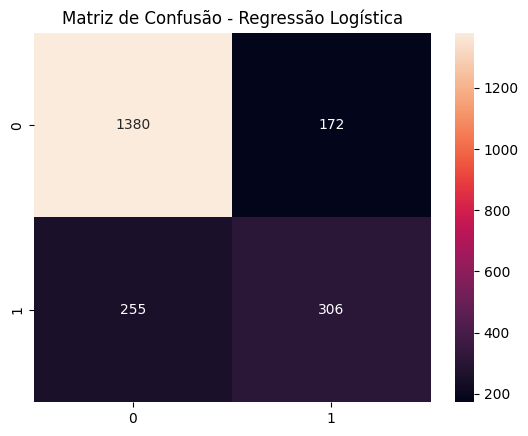

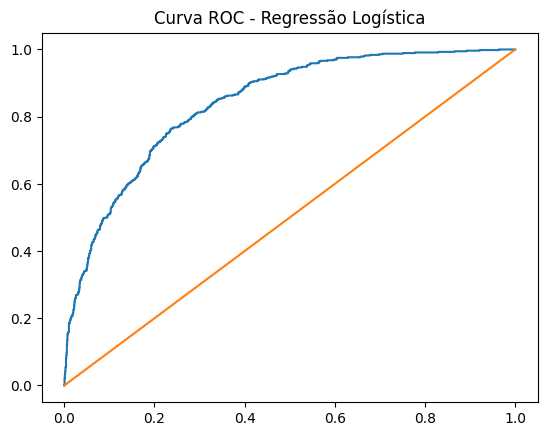


===== Random Forest =====
Acurácia: 0.7865593942262187
Precisão: 0.6227678571428571
Recall: 0.49732620320855614
F1-Score: 0.5530227948463825
ROC-AUC: 0.8227059099178566

Relatório:
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1552
        True       0.62      0.50      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113



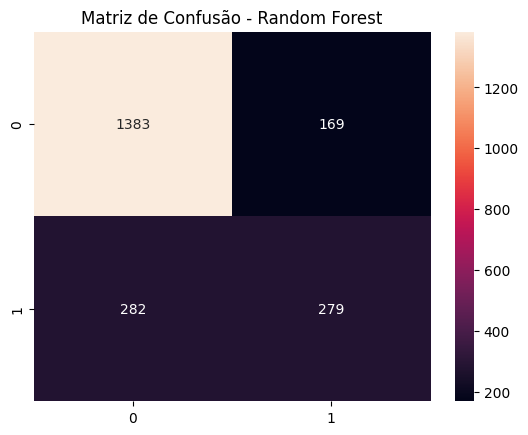

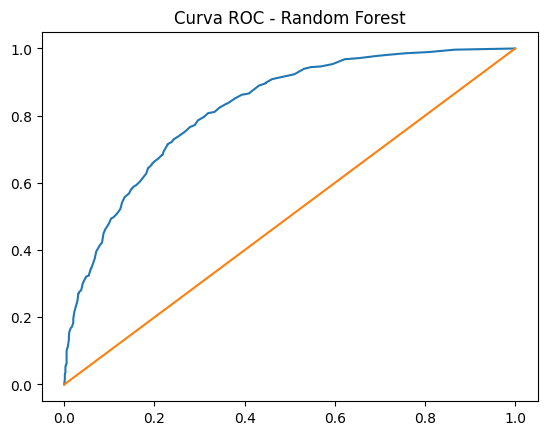


===== Gradient Boosting =====
Acurácia: 0.7917652626597255
Precisão: 0.627906976744186
Recall: 0.5294117647058824
F1-Score: 0.574468085106383
ROC-AUC: 0.8394027831376225

Relatório:
              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1552
        True       0.63      0.53      0.57       561

    accuracy                           0.79      2113
   macro avg       0.73      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113



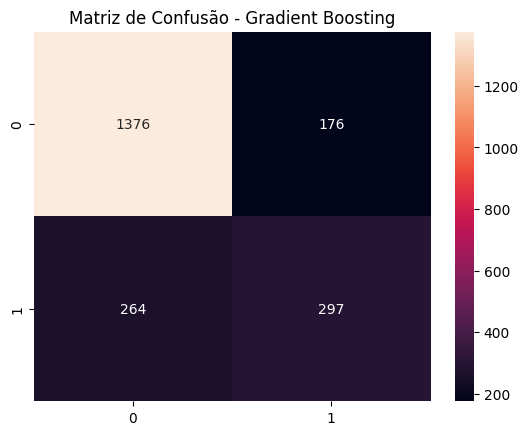

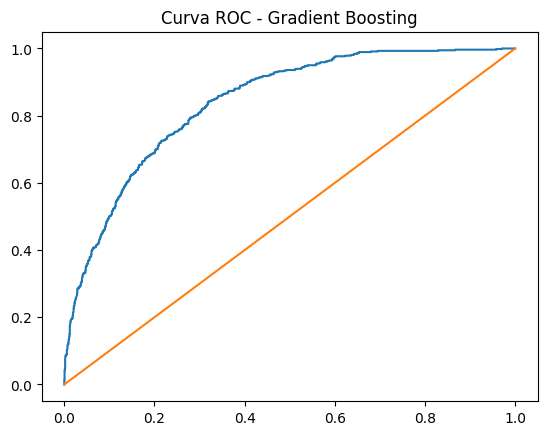

In [75]:
avaliar_modelo("Regressão Logística", modelo_lr)
avaliar_modelo("Random Forest", modelo_rf)
avaliar_modelo("Gradient Boosting", modelo_gb)

📌 PARTE 10 — Importância das Variáveis
- Random Forest

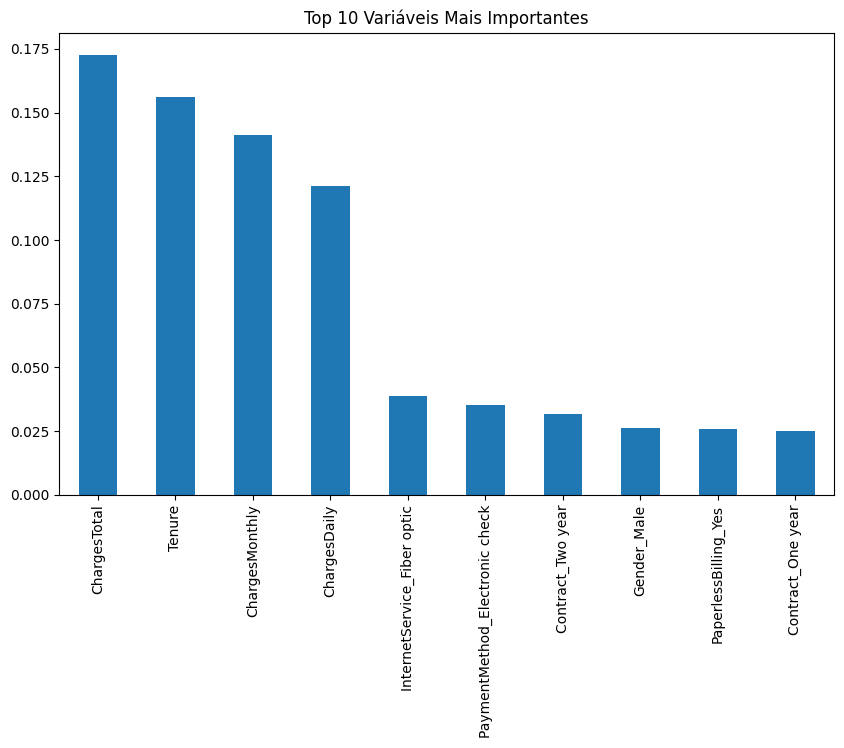

,0
ChargesTotal,0.172685
Tenure,0.156230
ChargesMonthly,0.141370
ChargesDaily,0.121324
InternetService_Fiber optic,0.038871
PaymentMethod_Electronic check,0.035401
Contract_Two year,0.031826
Gender_Male,0.026255
PaperlessBilling_Yes,0.025674
Contract_One year,0.024988


In [76]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(10).plot(kind="bar")
plt.title("Top 10 Variáveis Mais Importantes")
plt.show()

importancias.head(10)

🚀 GRÁFICO

📊 GRÁFICO 1 — Distribuição da Variável Alvo Churn

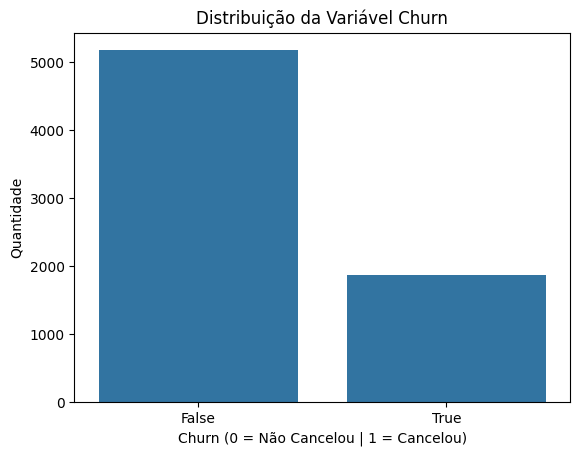

Proporção:
Churn_Yes
False    0.73463
True     0.26537
Name: proportion, dtype: float64


In [77]:
plt.figure()
sns.countplot(x=y)
plt.title("Distribuição da Variável Churn")
plt.xlabel("Churn (0 = Não Cancelou | 1 = Cancelou)")
plt.ylabel("Quantidade")
plt.show()

print("Proporção:")
print(y.value_counts(normalize=True))

🔥 GRÁFICO 2 — Matriz de Correlação

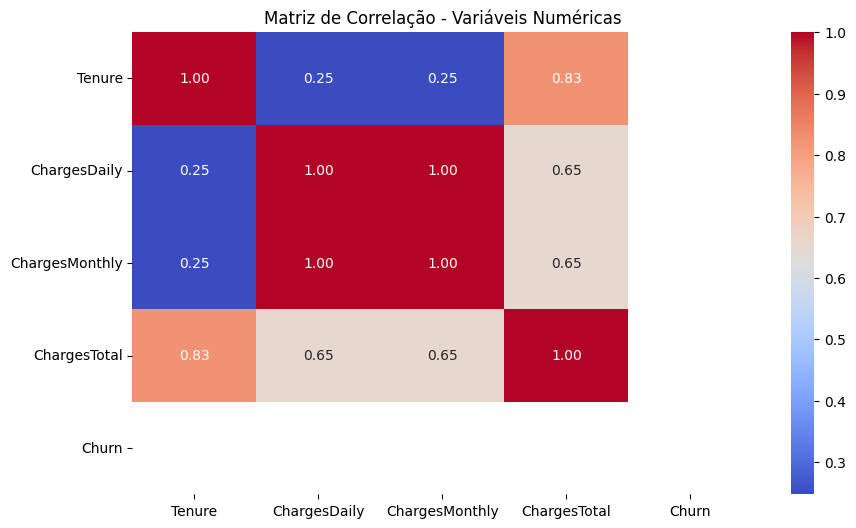

In [78]:
# Selecionar apenas variáveis numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Converter Churn para numérico
df_numeric["Churn"] = df["Churn_Yes"].map({"Yes": 1, "No": 0})


# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

📈 GRÁFICO 3 — Curva ROC Comparativa (3 Modelos)

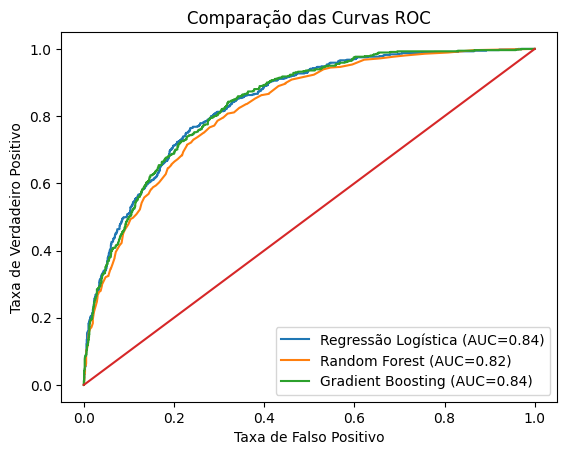

In [79]:
plt.figure()

for nome, modelo in {
    "Regressão Logística": modelo_lr,
    "Random Forest": modelo_rf,
    "Gradient Boosting": modelo_gb
}.items():

    y_prob = modelo.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.2f})")

plt.plot([0,1],[0,1])
plt.title("Comparação das Curvas ROC")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.legend()
plt.show()

📦 GRÁFICO 4 — Matriz de Confusão (Random Forest)

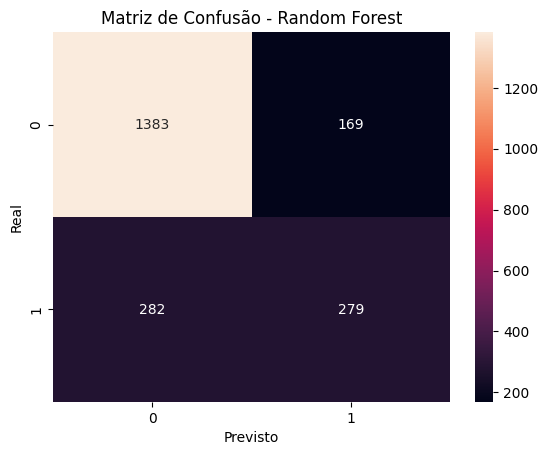

In [80]:
y_pred = modelo_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

🌳 GRÁFICO 5 — Importância das Variáveis

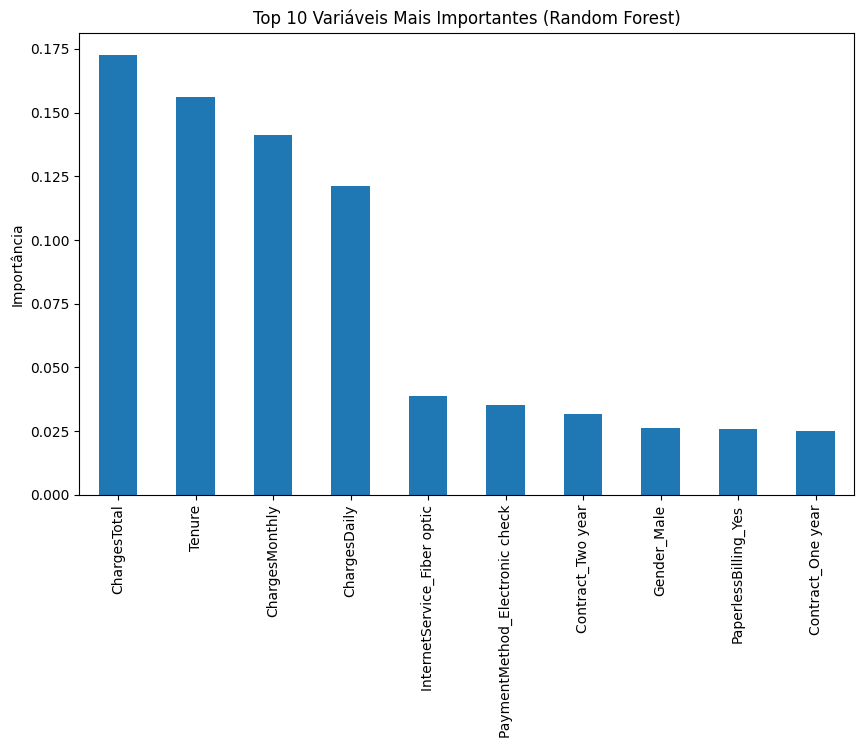

In [81]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(10).plot(kind="bar")
plt.title("Top 10 Variáveis Mais Importantes (Random Forest)")
plt.ylabel("Importância")
plt.show()

📊 GRÁFICO 6 — Distribuição das Probabilidades de Cancelamento

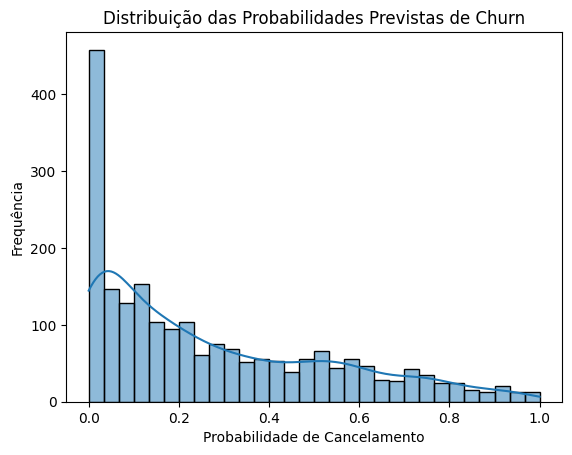

In [82]:
y_prob = modelo_rf.predict_proba(X_test)[:,1]

plt.figure()
sns.histplot(y_prob, bins=30, kde=True)
plt.title("Distribuição das Probabilidades Previstas de Churn")
plt.xlabel("Probabilidade de Cancelamento")
plt.ylabel("Frequência")
plt.show()

🏆 GRÁFICO — Comparação de Métricas

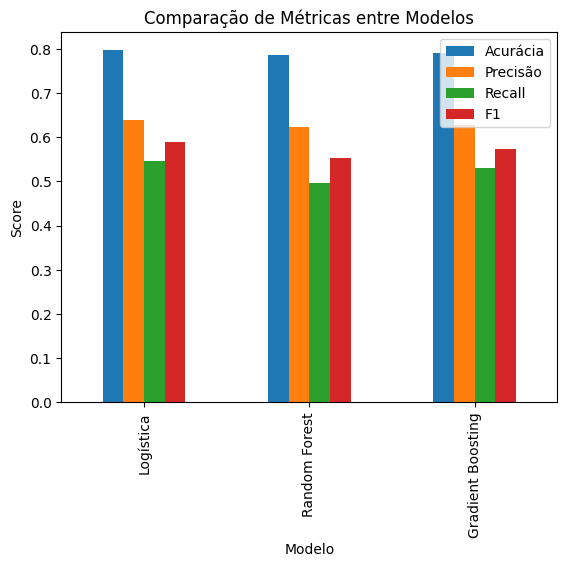

,Modelo,Acurácia,Precisão,Recall,F1
0,Logística,0.797918,0.640167,0.545455,0.589028
1,Random Forest,0.786559,0.622768,0.497326,0.553023
2,Gradient Boosting,0.791765,0.627907,0.529412,0.574468


In [83]:
resultados = []

for nome, modelo in {
    "Logística": modelo_lr,
    "Random Forest": modelo_rf,
    "Gradient Boosting": modelo_gb
}.items():

    y_pred = modelo.predict(X_test)
    resultados.append([
        nome,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

df_resultados = pd.DataFrame(resultados,
                             columns=["Modelo","Acurácia","Precisão","Recall","F1"])

df_resultados.set_index("Modelo").plot(kind="bar")
plt.title("Comparação de Métricas entre Modelos")
plt.ylabel("Score")
plt.show()

df_resultados

🏁 **Conclusão Geral do Projeto**

Após a comparação entre os modelos Regressão Logística, Random Forest e Gradient Boosting, a **Regressão Logística** apresentou o melhor desempenho global, destacando-se em todas as métricas avaliadas.

O modelo obteve:

Maior Recall (0.545) — métrica prioritária para o problema de churn

Maior F1-Score (0.589) — melhor equilíbrio entre precisão e detecção

Maior ROC-AUC (0.840) — melhor capacidade geral de separação entre clientes que cancelam e os que permanecem

Maior Acurácia (0.798) — melhor desempenho global

Como o objetivo estratégico da Telecom X é identificar o maior número possível de clientes com risco real de cancelamento, o Recall foi definido como métrica principal, pois reduz Falsos Negativos — situação mais crítica para o negócio, representando perda direta de receita.

Embora modelos baseados em árvores sejam mais complexos, a Regressão Logística demonstrou desempenho superior e maior interpretabilidade, permitindo compreender quais variáveis impactam diretamente a evasão.